# **Group Project #2: Team Data Pioneers**

##### **Group Members**: Raquel Tartt, Kawika Keys, Oluwagbemisoke Soneye, Mehlik Thomas, and Maryshawnt Obilor
##### MATH 014- Data Science
##### Data Visualization and Storytelling
##### 04/12/2026

## **Table of Contents**
#### ***Section 1: Individual & Comparative Visualizations***
##### **Task 1: Individual Visualizations**
##### **Task 2: Comparative Visualizations**
#### ***Section 2: Relationship Visualizations***
##### **Task 3: Relationship Analysis**

Data Set Link: https://catalog.data.gov/dataset/daily-arrests

In [3]:
import pandas as pd
df = pd.read_csv("Daily_Arrests.csv")

---

### **Task 01**: Individual Visualizations

In [4]:
import pandas as pd 
import matplotlib.pyplot as plt 

df = pd.read_csv("Daily_Arrests.csv")
df.columns = df.columns.str.strip()

Text(0.5, 1.0, 'Distribution of Age')

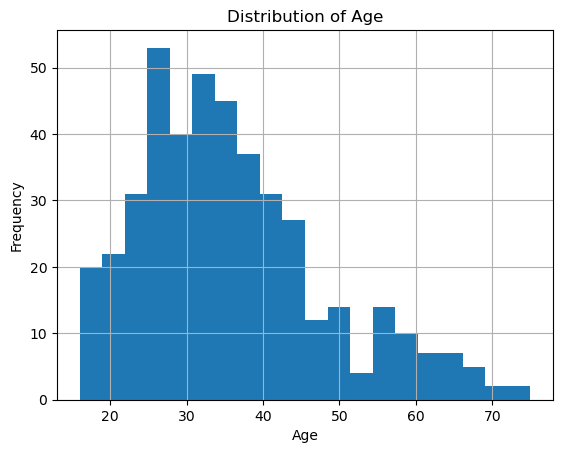

In [81]:
plt.figure()
df['AGE'].hist(bins=20)
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Distribution of Age")

#### This histogram helps us visualize the frequency of different age values. The lines divide the age data into 20 bins and counts how many individuals fall into each bin.

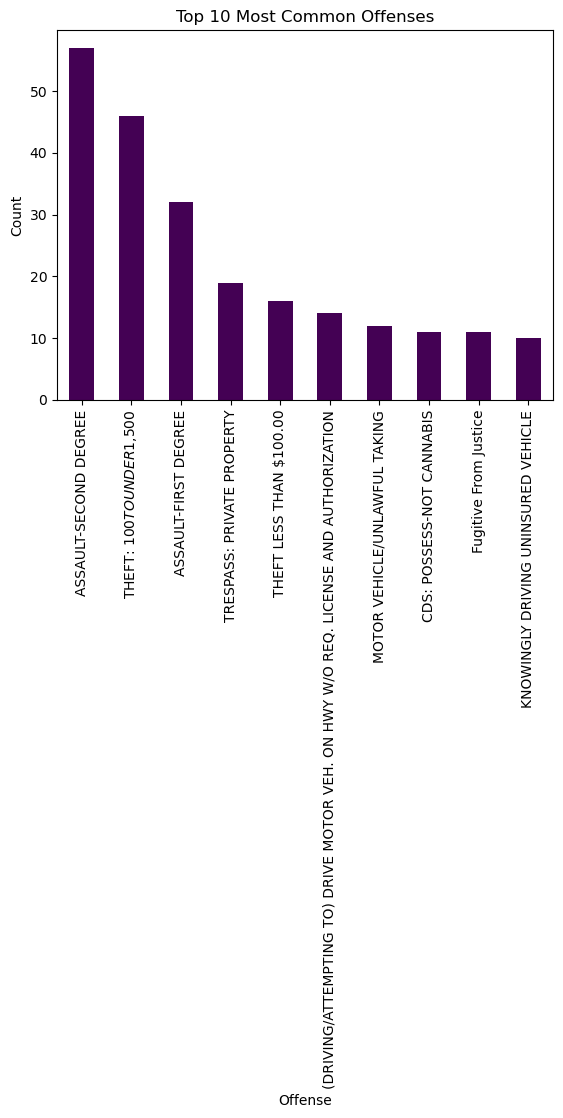

In [105]:
plt.figure()
df['OFFENSE'].value_counts().head(10).plot(
    kind='bar',colormap='viridis')
plt.xlabel("Offense")
plt.ylabel("Count") 
plt.title("Top 10 Most Common Offenses")
plt.xticks(rotation=90)
plt.show()

#### The bar chart is used to visualize the most common offense. Through this visualization, it is illustrated that Assault in the second degree is the most common offense committed. 

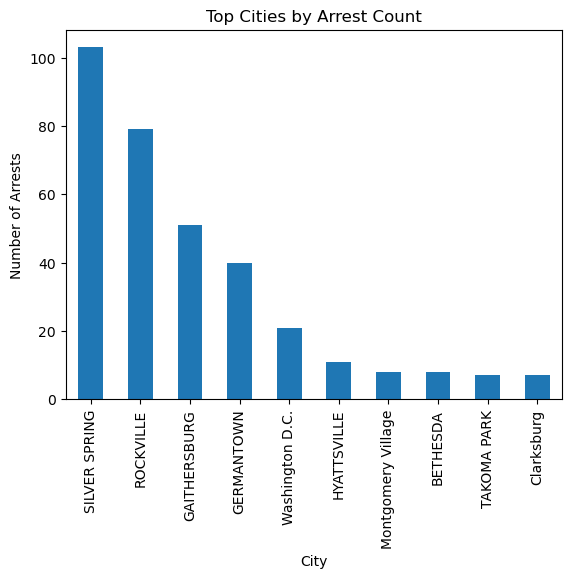

In [19]:
plt.figure()
df['CITY'].value_counts().head(10).plot(kind='bar')
plt.xlabel("City")
plt.ylabel("Number of Arrests")
plt.title("Top Cities by Arrest Count")
plt.xticks(rotation=90)
plt.show()

#### The bar graph is used to display the number of arrests that occur in each city. This visualization could provide insight into crime hotspots and geographical patterns 

In [22]:
import seaborn as sns

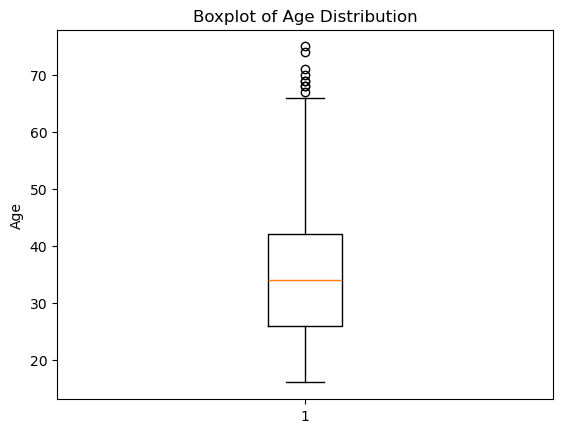

In [21]:
plt.figure()
plt.boxplot(df['AGE'])
plt.ylabel("Age")
plt.title("Boxplot of Age Distribution")
plt.show()

#### The boxplot is used to summarize and visualize the distribution of age, including its central tendency, spread, and  outliers.

### **Task 02**: Comparative Visualizations

In [51]:
df['OFFENSE'].nunique()

103

In [55]:
counts = df['OFFENSE'].value_counts()
counts[counts > 5]

OFFENSE
ASSAULT-SECOND DEGREE                                                                       57
THEFT: $100 TO UNDER $1,500                                                                 46
ASSAULT-FIRST DEGREE                                                                        32
TRESPASS: PRIVATE PROPERTY                                                                  19
THEFT LESS THAN $100.00                                                                     16
(DRIVING/ATTEMPTING TO) DRIVE MOTOR VEH. ON HWY W/O REQ. LICENSE AND AUTHORIZATION          14
MOTOR VEHICLE/UNLAWFUL TAKING                                                               12
CDS: POSSESS-NOT CANNABIS                                                                   11
Fugitive From Justice                                                                       11
KNOWINGLY DRIVING UNINSURED VEHICLE                                                         10
VIOLATE PROTECTIVE ORDER                  

In [60]:
frequent_offenses = counts[counts > 10].index
filtered_df = df[df['OFFENSE'].isin(frequent_offenses)]

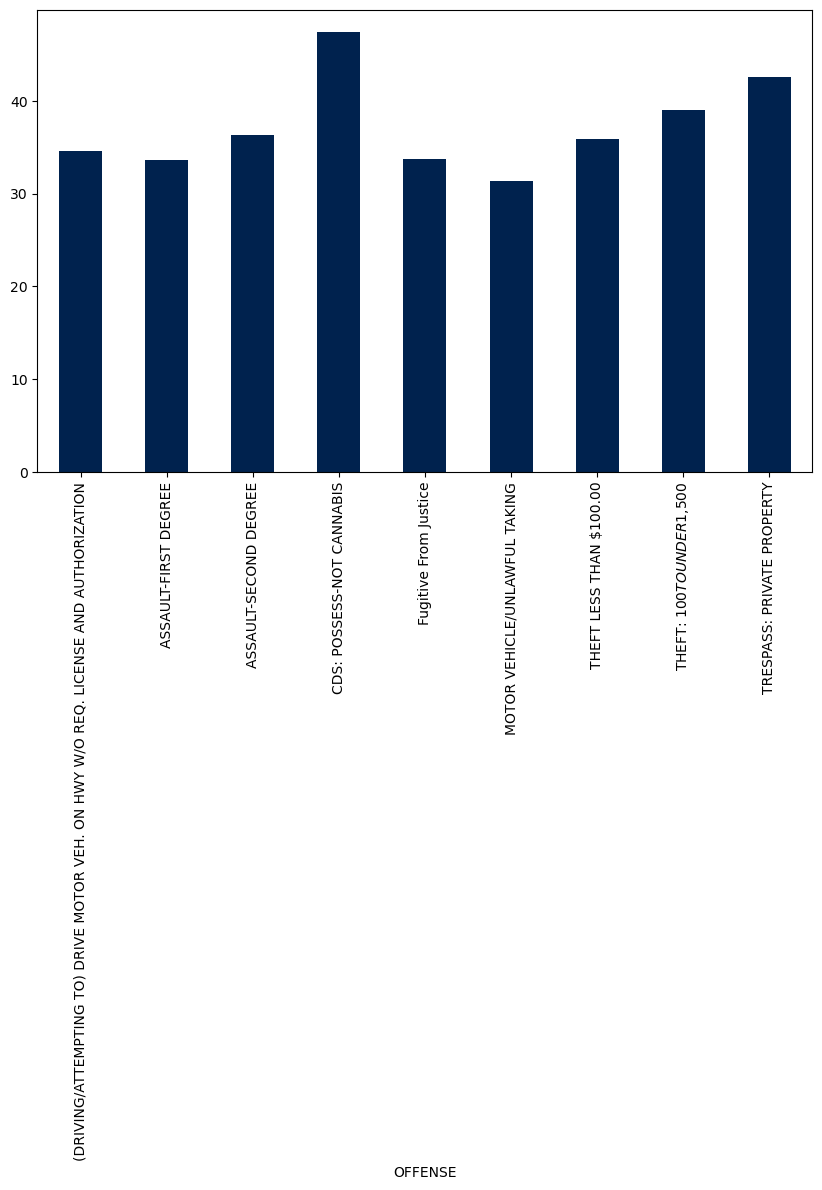

In [113]:
plt.figure(figsize=(10,6))
filtered_df.groupby('OFFENSE')['AGE'].mean().head(30).plot(
    kind='bar', colormap='cividis')
plt.xticks(rotation=90)
plt.show()

#### The visualization shows the average ages of perpetrators across the most common offense type. This visualization suggests that different crimes are associated with different age groups. For example, offenses such as armed robbery may involve younger individuals, while other offenses, such as second-degree arson, show higher average ages.

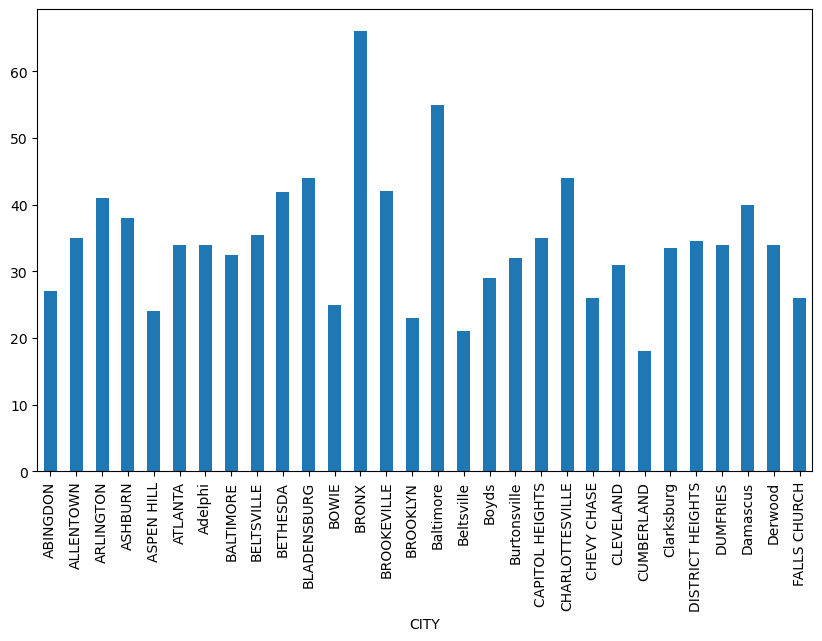

In [77]:
plt.figure(figsize=(10,6))
df.groupby('CITY')['AGE'].mean().head(30).plot(kind='bar')
plt.show()

#### This bar graph displays the average age of offenders in a number of cities represented in the data set.

### **Task 03**: Relationship Analysis 

Text(0, 0.5, 'Age')

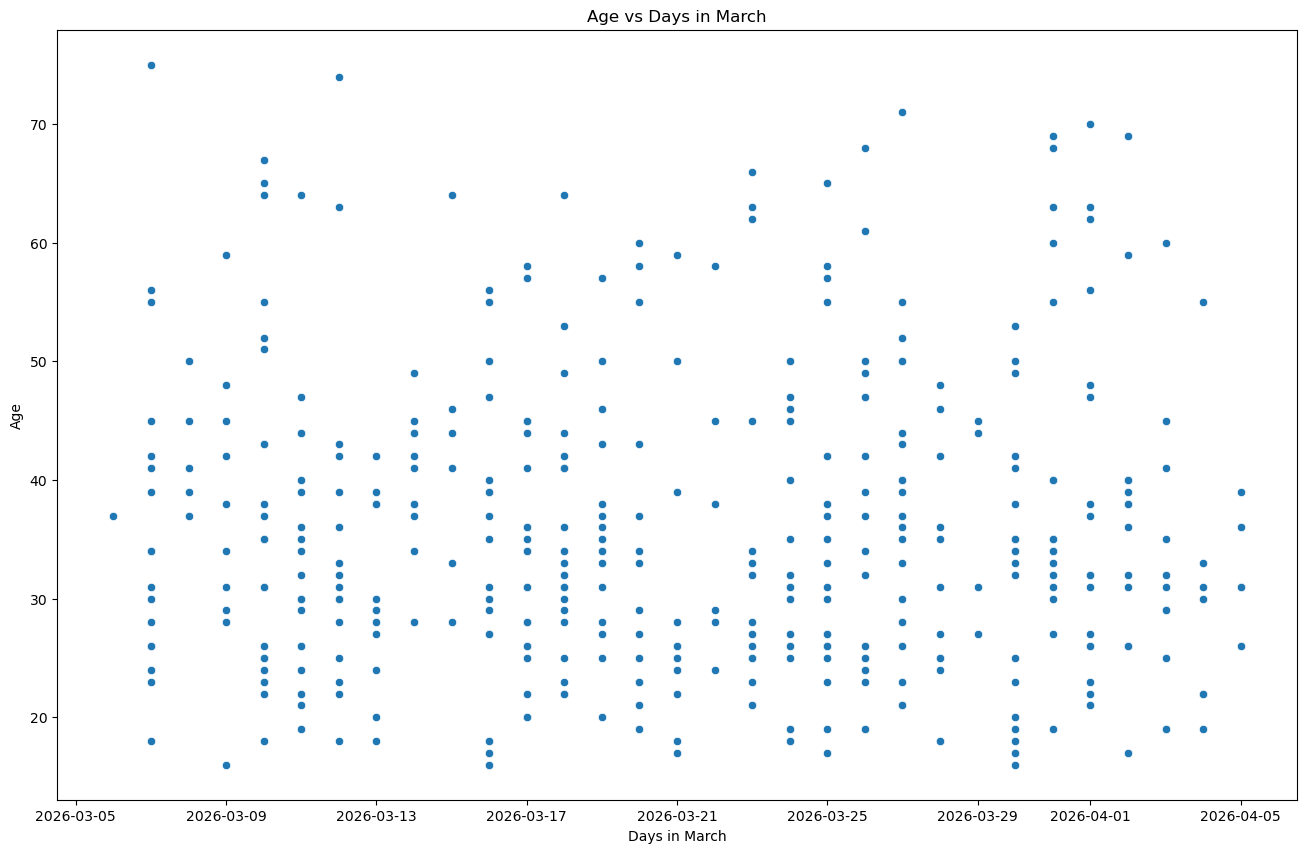

In [71]:
import seaborn as sns
import matplotlib.pyplot as plt
df['ARREST DATE'] = pd.to_datetime(df['ARREST DATE'])
df['Month'] = df['ARREST DATE'].dt.month
df['Arrest_Day'] = df['ARREST DATE'].dt.day
march_data = df[df['Month'] == 3].copy()
plt.figure(figsize=(16, 10))
sns.scatterplot(data=df, x="ARREST DATE", y="AGE")
plt.title("Age vs Days in March")
plt.xlabel("Days in March")
plt.ylabel("Age")

Text(170.72222222222223, 0.5, 'Age')

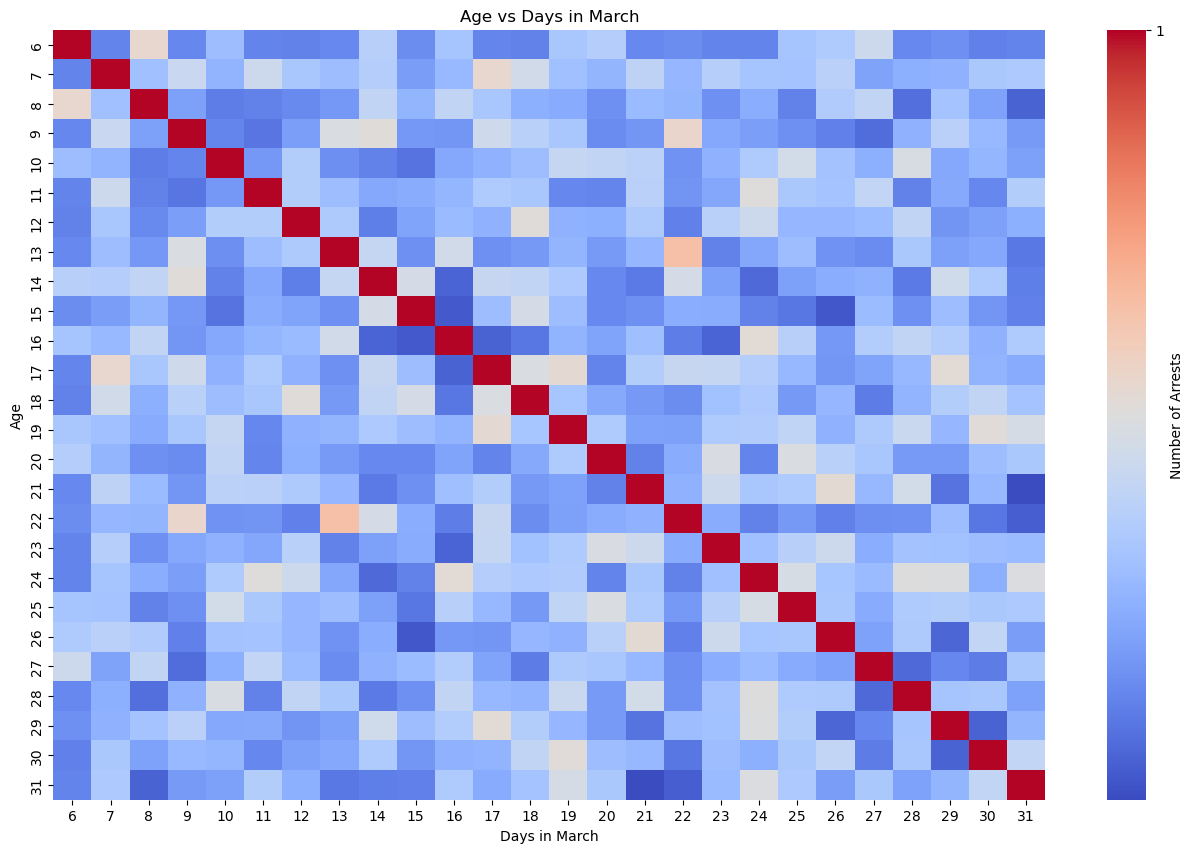

In [73]:
heatmap_data = pd.crosstab(march_data["AGE"], march_data["Arrest_Day"])
march_corr = heatmap_data.corr()

plt.figure(figsize=(16, 10))
sns.heatmap(march_corr, annot=False, cmap="coolwarm", cbar_kws={"ticks": [1, 2, 3, 4, 5], "label": "Number of Arrests"})
plt.title("Age vs Days in March")
plt.xlabel("Days in March")
plt.ylabel("Age")

#### Since the data consisted of arrests from different people in different states, it was expected that the scatter plot would likely not show a correlation between the two variables. As predicted, the scatter plot of Age vs Days in March yielded no correlation between the two variables. In the heatmap, given that there are a select few boxes that are very red, it shows that many of the people included in the data had more than one offense. Interestingly, the red boxes are lined up in a diagonal line, mimicking a negative slope line, showing that the older the people were, the more likley their only offense occured later in the month of March.